In [3]:
import pandas as pd
import duckdb
from constants import GRAY_1, GRAY_2, GRAY_3, BLUE_1

df = pd.read_csv("norway_new_car_sales_by_make.csv")
df.head(3)

,Year,Month,Make,Quantity,Pct
0,2007,1,Toyota,2884,22.7
1,2007,1,Volkswagen,2521,19.9
2,2007,1,Peugeot,1029,8.1


In [20]:
df_qty_brand = duckdb.sql("""--sql
SELECT
    make AS Brand,
    SUM(quantity) AS Quantity
FROM df
GROUP BY Brand
ORDER BY Quantity DESC
""").df().set_index("Brand")

df_qty_brand.head()

,Quantity
Brand,
Volkswagen,206669.0
Toyota,168177.0
Volvo,99937.0
Ford,99713.0
BMW,73315.0


# Bar charts


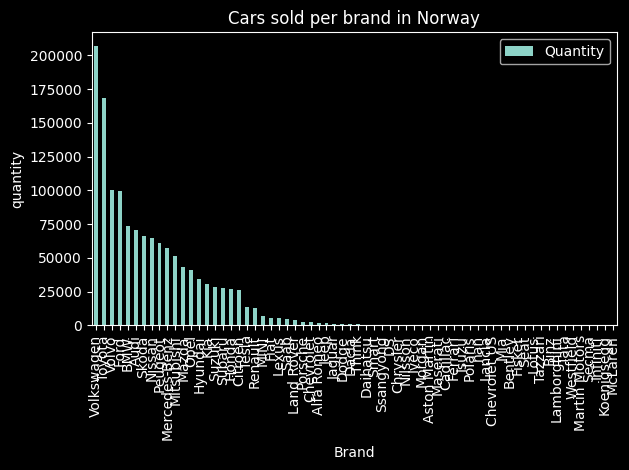

In [107]:
ax = df_qty_brand.plot(kind = "bar", y="Quantity")
ax.set(title= "Cars sold per brand in Norway", ylabel= "quantity")
fig = ax.get_figure()

fig.tight_layout()
fig.savefig("figures/cars_brand_sold.png", dpi=150)

## Focus on 10 top brands

In [28]:
df_top_10_brands = df_qty_brand.iloc[:10]
df_top_10_brands

,Quantity
Brand,
Volkswagen,206669.0
Toyota,168177.0
Volvo,99937.0
Ford,99713.0
BMW,73315.0
Audi,70475.0
Skoda,66007.0
Nissan,64535.0
Peugeot,61033.0


<Axes: title={'center': 'Top cars sold in Norway'}, xlabel='Brand', ylabel='Number cars'>

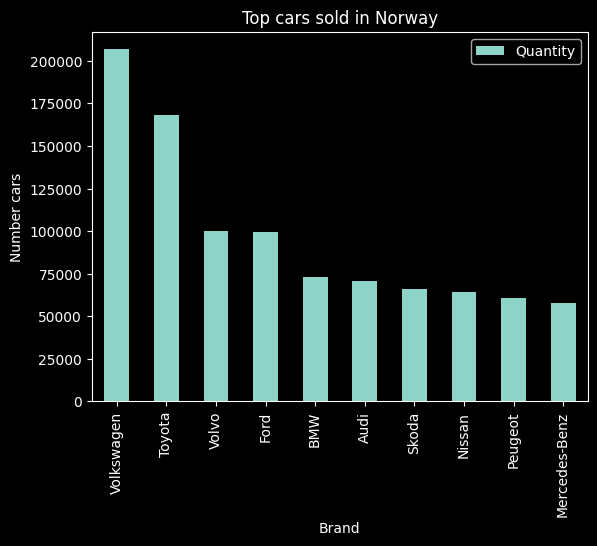

In [30]:
df_top_10_brands.plot(kind="bar", title="Top cars sold in Norway", ylabel="Number cars")

# TODO: export this graph

## Data storytelling
- attention
- contrast
- descriptive title
- proximity with annotation
- remove clutter
- horizontal bar (hbar)
- clear xlabel and ylabel
- precentage instead of absolute value

In [35]:
total_quantity = df_qty_brand["Quantity"].sum()

df_percentage = df_top_10_brands["Quantity"]/total_quantity*100
df_percentage

Brand
Volkswagen       15.340063
Toyota           12.482984
Volvo             7.417851
Ford              7.401225
BMW               5.441826
Audi              5.231026
Skoda             4.899388
Nissan            4.790128
Peugeot           4.530191
Mercedes-Benz     4.272184
Name: Quantity, dtype: float64

In [91]:
colors = [GRAY_2]*len(df_percentage)
colors[2] = BLUE_1
colors

['#657072',
 '#657072',
 '#1E4E5C',
 '#657072',
 '#657072',
 '#657072',
 '#657072',
 '#657072',
 '#657072',
 '#657072']

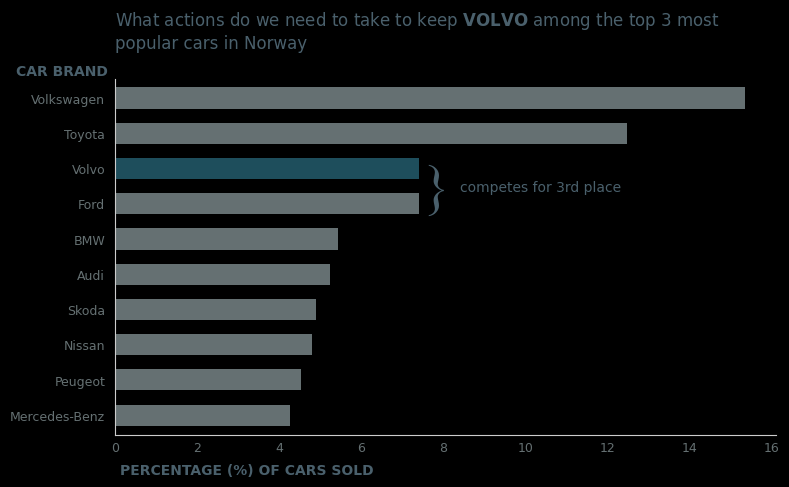

In [106]:
ax = df_percentage.plot(kind="barh", figsize=(8,5), width=.6, color=colors) # width == tjocklek på barsen

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRAY_1)

ax.tick_params(axis="both", colors=GRAY_2, labelsize=9, length=0, pad=5) # length==strecken vid värderna
ax.tick_params(axis="y", pad=7)

ax.set_xlabel("PERCENTAGE (%) OF CARS SOLD", color=GRAY_3, fontweight="bold")
ax.set_ylabel("CAR BRAND", color=GRAY_3, fontweight="bold", rotation=0)

ax.yaxis.set_label_coords(-.08, 1)
ax.xaxis.set_label_coords( .2, -.08)

ax.set_title(
    "What actions do we need to take to keep"
    + r" $\bf{VOLVO}$"
    + " among the top 3 most \npopular cars in Norway",
    loc="left",
    color=GRAY_3,
    pad=22,
)

ax.invert_yaxis()

ax.annotate(xy=(8.4, 2.65), text="competes for 3rd place", color=GRAY_3, fontsize=10)
ax.annotate(xy=(7.5, 2.97), text="}", color=GRAY_3, fontsize=40, family="Times New Roman")

fig = ax.get_figure()

fig.tight_layout()
fig.savefig("figures/volvo_storytelling.png", dpi=150)